In [2]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [3]:
df = pd.read_csv('gemini.csv')

In [4]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
model = CatBoostClassifier(
    iterations=500,           # для маленьких данных лучше меньше итераций + раннее стоппинг
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced', # Решает проблему дисбаланса 0 и 1
    eval_metric='F1',          # Оптимизируем под дисбаланс, а не под точность
    verbose=100,               # Выводить лог каждые 100 шагов
    random_seed=42
)

# 3. Обучение с защитой от переобучения
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50   # Остановится, если F1 перестанет расти
)

# 4. Получение вероятностей
y_proba = model.predict_proba(X_test)[:, 1]

# 5. Предсказание классов
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

0:	learn: 0.9411765	test: 0.8333333	best: 0.8333333 (0)	total: 94.5ms	remaining: 47.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8333333333
bestIteration = 0

Shrink model to first 1 iterations.
              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83         6
         1.0       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



In [6]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 83.33%


Accuracy:0.833
Precision:0.833
Recall:  0.833
F1-score: 0.833

Confusion Matrix:
 [[5 1]
 [1 5]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.83      0.83         6
         1.0       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12

0:	learn: 1.0000000	total: 1.05ms	remaining: 522ms
100:	learn: 1.0000000	total: 54.2ms	remaining: 214ms
200:	learn: 1.0000000	total: 105ms	remaining: 156ms
300:	learn: 1.0000000	total: 154ms	remaining: 102ms
400:	learn: 1.0000000	total: 200ms	remaining: 49.3ms
499:	learn: 1.0000000	total: 247ms	remaining: 0us
0:	learn: 1.0000000	total: 636us	remaining: 318ms
100:	learn: 1.0000000	total: 53.5ms	remaining: 211ms
200:	learn: 1.0000000	total: 107ms	remaining: 159ms
300:	learn: 1.0000000	total: 151ms	remaining: 100ms
400:	learn: 1.0000000	total: 195m

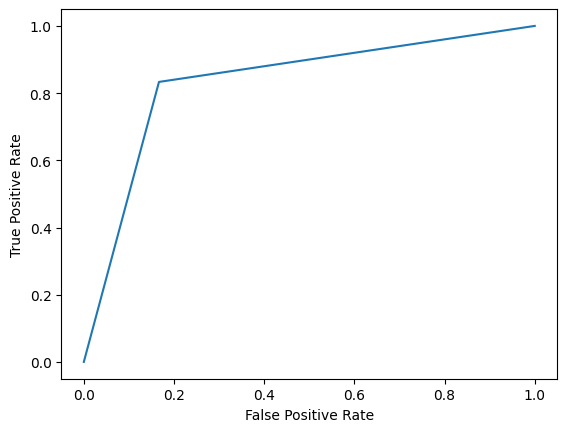

In [7]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [8]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.833
Precision:0.833
Recall:  0.833
F1-score: 0.833
ROC-AUC:0.903

Confusion Matrix:
 [[5 1]
 [1 5]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.83      0.83         6
         1.0       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



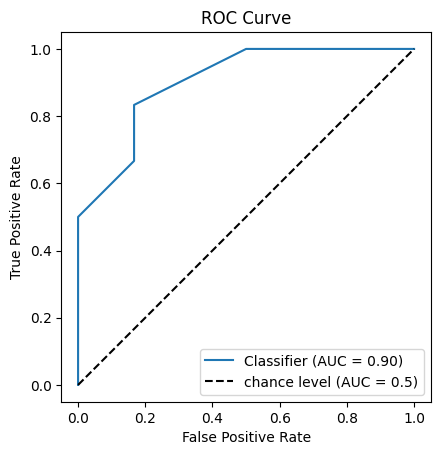

In [9]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

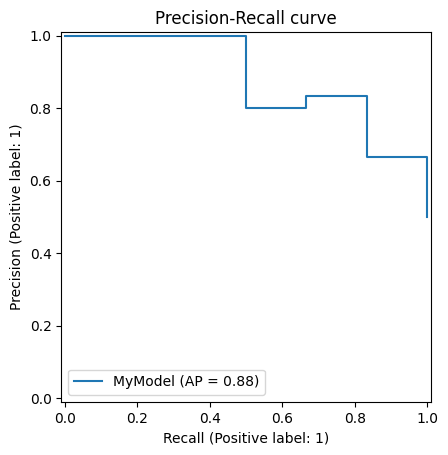

In [10]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()

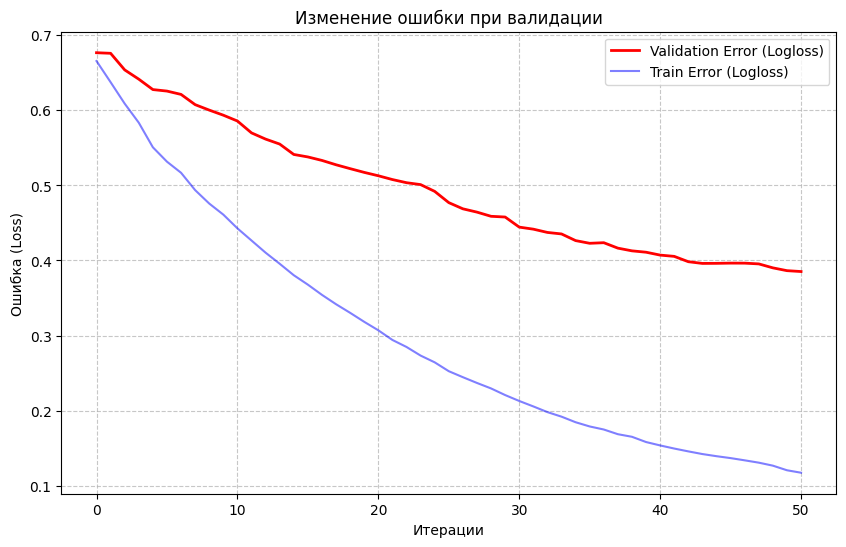

In [ ]:
import matplotlib.pyplot as plt

# Обучение (используем твой объект model)
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    verbose=False
)

# Извлекаем данные
results = model.get_evals_result()
# CatBoost по умолчанию считает Logloss, если не указано иное
train_loss = results['learn']['Logloss']
test_loss = results['validation']['Logloss']
iterations = range(len(train_loss))

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(iterations, test_loss, label='Validation Error (Logloss)', color='red', linewidth=2)
# Опционально добавим линию тренировочной ошибки для сравнения
plt.plot(iterations, train_loss, label='Train Error (Logloss)', color='blue', alpha=0.5)

plt.xlabel('Итерации')
plt.ylabel('Ошибка (Loss)')
plt.title('Изменение ошибки при валидации')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
